# Asset portfolio evaluation

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RiskThinking/crc-docs/blob/main/notebooks/asset_portfolio_evaluation.ipynb) · [GitHub preview](https://github.com/RiskThinking/crc-docs/blob/main/notebooks/asset_portfolio_evaluation.ipynb)

**crc-sdk**'s fluent portfolio API turns a canonical hazard Parquet and a table of
point assets into per-asset return-period depths:

```text
HazardDataset.local(...).for_assets(...).select(...).return_periods(...).write_parquet(...)
```

1. **Assets** — three warehouses near Cologne, with sector and replacement value.
2. **Hazard** — reuse the checked-in hurdle-canonical WRI riverine fixture.
3. **Evaluate** — stream RP depths for every asset; Plotly maps and compares them.

The small fixture under `fixtures/os_climate/` keeps this notebook fully offline.


**Workflow:** [AI skill](https://github.com/RiskThinking/crc-docs/blob/main/.agents/skills/crc-assess-asset-portfolio-risk/SKILL.md) · [Python pipeline](https://github.com/RiskThinking/crc-docs/blob/main/pipelines/asset_portfolio_pipeline.py) · [Setup and tested versions](https://github.com/RiskThinking/crc-docs/blob/main/ai-playbooks/docs/setup.md) · [All problems](https://github.com/RiskThinking/crc-docs/blob/main/README.md#choose-a-problem)

### Viewing this notebook

**GitHub:** saved tables and PNG figures below show the completed run; no execution
is needed. **Colab / JupyterLab / compatible editors:** run all cells for interactive
Plotly charts with hover, zoom and pan. Each figure also includes a static PNG
fallback. Maps need internet access for basemap tiles; PMTiles downloads, where
provided, open separately in a compatible viewer.


## Setup — run this first

In Colab, choose **Runtime → Run all** using a standard CPU runtime (Python 3.12+).
The next cell installs this notebook's Python packages, prepares required files,
and installs Chrome if PNG rendering needs it. No clone, `uv`, API key or GPU is
required. If a package was already imported and changes version, restart the
session once and run all again. Downloads and outputs live in the runtime;
download anything you want to keep before the session ends.


In [1]:
#@title Install dependencies and prepare this notebook
import hashlib
import importlib
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import shutil
import subprocess
import sys
import sysconfig
import urllib.request

if sys.version_info < (3, 12):
    raise RuntimeError("Use a Python 3.12+ runtime (Colab: Runtime > Change runtime type).")

# Install into this kernel's Python, not a separate shell environment.
REQUIREMENTS = ['crc-sdk[geometry]==0.7.1', 'crc-framework==0.2.5', 'numpy>=1.26,<3', 'pandas>=2.2,<4', 'plotly==6.9.0', 'kaleido==1.3.0', 'nbformat>=5.10,<6']
loaded_versions = {
    module: getattr(sys.modules[module], "__version__", None)
    for module in ("numpy", "pandas", "pyarrow", "plotly", "crc_sdk", "crc_framework")
    if module in sys.modules
}
if importlib.util.find_spec("pip") is None:
    subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check",
    *REQUIREMENTS,
])
importlib.invalidate_caches()
for module, loaded in loaded_versions.items():
    installed = importlib.metadata.version(module.replace("_", "-"))
    if loaded is not None and loaded != installed:
        raise RuntimeError("Packages changed after import. Restart the kernel/session, then run all cells again.")
os.environ["PATH"] = sysconfig.get_path("scripts") + os.pathsep + os.environ.get("PATH", "")
IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False

# A local checkout keeps its files; standalone/Colab runs download only required resources.
RESOURCE_REVISION = '52ff7a93028cc1e64f3b1df856851650df825dc8'
RESOURCE_SHA256 = {'fixtures/os_climate/hazard.parquet': '60550f032692da9a824ff3a832dd142d4732717ff2a7e6084781d803c73a6c96', 'fixtures/os_climate/assets.parquet': '1150ddb98d339e79bd3f647f109c523a498edac8393d71bc9f9d4b2aec37f5d8'}
REPO_ROOT = next((
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "pyproject.toml").is_file()
    and 'name = "crc-docs"' in (folder / "pyproject.toml").read_text()
), None)
if REPO_ROOT is None:
    REPO_ROOT = next((
        folder for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / ".crc-notebook-revision").is_file()
        and (folder / ".crc-notebook-revision").read_text() == RESOURCE_REVISION
    ), Path.cwd() / ".crc-docs" / RESOURCE_REVISION)
    REPO_ROOT.mkdir(parents=True, exist_ok=True)
    (REPO_ROOT / ".crc-notebook-revision").write_text(RESOURCE_REVISION)
    for relative, expected_hash in RESOURCE_SHA256.items():
        target = REPO_ROOT / relative
        if not target.exists() or hashlib.sha256(target.read_bytes()).hexdigest() != expected_hash:
            url = f"https://raw.githubusercontent.com/RiskThinking/crc-docs/{RESOURCE_REVISION}/{relative}"
            with urllib.request.urlopen(url, timeout=120) as response:
                content = response.read()
            if hashlib.sha256(content).hexdigest() != expected_hash:
                raise RuntimeError(f"Resource checksum mismatch: {relative}")
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_bytes(content)
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(NOTEBOOK_DIR)

# Kaleido needs Chrome for the PNG fallback. Download it only when it is missing.
import plotly.graph_objects as go
import plotly.io as pio
from choreographer.browsers.chromium import ChromeNotFoundError
try:
    pio.to_image(go.Figure(go.Scatter(x=[0, 1], y=[0, 1])), format="png", width=100, height=100)
except RuntimeError as error:
    if not isinstance(error.__context__, ChromeNotFoundError):
        raise
    os.environ["BROWSER_PATH"] = str(pio.get_chrome())
    pio.to_image(go.Figure(go.Scatter(x=[0, 1], y=[0, 1])), format="png", width=100, height=100)
print(f"Ready: Python {sys.version.split()[0]}, crc-sdk {importlib.metadata.version('crc-sdk')}")
print(f"Working directory: {NOTEBOOK_DIR}")


Ready: Python 3.12.10, crc-sdk 0.7.1
Working directory: /Users/woozyking/rtai/crc-docs/notebooks


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pyarrow.parquet as pq

from crc_sdk.connectors import read_hazard_dataset
from crc_sdk.workflows import ExecutionOptions, HazardDataset, return_period_value_columns

# GitHub's notebook preview only renders static HTML/images (no JS execution),
# so every fig.show() below emits both an interactive widget (for local/Jupyter
# use) and a static PNG fallback (via kaleido) that GitHub's viewer displays.
# One MIME bundle: interactive Plotly where supported, PNG for GitHub.
pio.renderers.default = "colab+plotly_mimetype+png" if IN_COLAB else "plotly_mimetype+png"
pio.renderers["png"].width = 1100
pio.renderers["png"].height = 550
pio.renderers["png"].scale = 1

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
FIXTURE_DIR = Path("../fixtures/os_climate")

LONGITUDE = 6.9603
LATITUDE = 50.9375
HAZARD_NAME = "RiverineInundation"
PATHWAY = "historical"
HORIZON = 1980
RETURN_PERIODS = [25, 50, 100, 250, 500, 1000]

HAZARD_PATH = FIXTURE_DIR / "hazard.parquet"
ASSETS_PATH = FIXTURE_DIR / "assets.parquet"
EVAL_PATH = DATA_DIR / "cologne_portfolio_evaluation.parquet"


## 1. Portfolio assets

A tiny but distinct portfolio: three points inside one source pixel so the
hazard match is unambiguous, with enough attribute variety to show passthrough
columns survive into the evaluation output.


In [3]:
assets = pq.read_table(ASSETS_PATH)
print(f"{assets.num_rows} assets <- {ASSETS_PATH}")
assets.to_pandas()


3 assets <- ../fixtures/os_climate/assets.parquet


,asset_id,longitude,latitude,sector,replacement_value
0,warehouse-a,6.96030,50.93750,logistics,12000000
1,warehouse-b,6.96031,50.93751,logistics,8500000
2,warehouse-c,6.96029,50.93749,manufacturing,21000000


## 2. Canonical hazard around the assets

The checked-in fixture retains the live ingest's canonical rows, source geometry,
curve parameters, and metadata. Reading it validates that contract before the
portfolio evaluation starts.


In [4]:
hazard = read_hazard_dataset(HAZARD_PATH)
print(f"{hazard.num_rows} canonical hazard rows <- {HAZARD_PATH}")


11 canonical hazard rows <- ../fixtures/os_climate/hazard.parquet


## 3. Evaluate return periods for every asset

`HazardDataset` is a thin facade over `LocalProvider`. `.select` filters the
canonical scenario dimensions; `.return_periods` asks for upper-tail depths;
`.write_parquet` streams the join + curve reconstruction out of core.


In [5]:
result = (
    HazardDataset.local(HAZARD_PATH)
    .for_assets(ASSETS_PATH)
    .select(
        hazard_names=[HAZARD_NAME],
        horizons=[HORIZON],
        pathways=[PATHWAY],
    )
    .return_periods(RETURN_PERIODS)
    .write_parquet(EVAL_PATH, execution=ExecutionOptions(max_workers=1))
)
evaluated = pq.read_table(EVAL_PATH).to_pandas()
print(f"evaluated rows: {result.row_count}")
print(f"value columns: {', '.join(result.value_columns)}")
evaluated


evaluated rows: 3
value columns: value_rp25, value_rp50, value_rp100, value_rp250, value_rp500, value_rp1000


,asset_id,sector,replacement_value,longitude,latitude,cell_index,hazard_name,horizon,pathway,source_id,spatial_match,value_rp25,value_rp50,value_rp100,value_rp250,value_rp500,value_rp1000
0,warehouse-b,logistics,8500000,6.96031,50.93751,617549611779227647,RiverineInundation,1980,historical,bfb78f711ac2e5a6d314ffacec29b9e236c730d9a6031c...,exact_geometry,1.098854,1.400417,1.701981,2.100626,2.402189,2.703752
1,warehouse-c,manufacturing,21000000,6.96029,50.93749,617549611779227647,RiverineInundation,1980,historical,bfb78f711ac2e5a6d314ffacec29b9e236c730d9a6031c...,exact_geometry,1.098854,1.400417,1.701981,2.100626,2.402189,2.703752
2,warehouse-a,logistics,12000000,6.96030,50.93750,617549611779227647,RiverineInundation,1980,historical,bfb78f711ac2e5a6d314ffacec29b9e236c730d9a6031c...,exact_geometry,1.098854,1.400417,1.701981,2.100626,2.402189,2.703752


## 4. Visualize


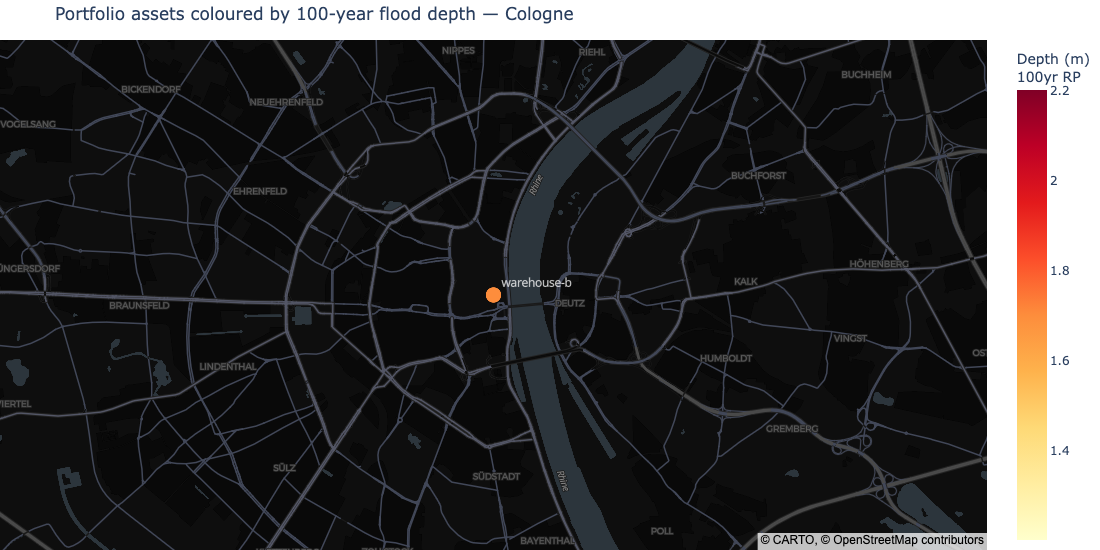

In [6]:
MAP_STYLE = "carto-darkmatter"
design_col = return_period_value_columns([100])[0]

fig_map = go.Figure(
    go.Scattermap(
        lat=evaluated["latitude"],
        lon=evaluated["longitude"],
        mode="markers+text",
        text=evaluated["asset_id"],
        textposition="top right",
        textfont=dict(color="white"),
        marker=dict(
            size=16,
            color=evaluated[design_col],
            colorscale="YlOrRd",
            colorbar_title="Depth (m)<br>100yr RP",
            showscale=True,
        ),
        customdata=np.stack(
            [evaluated["sector"], evaluated["replacement_value"], evaluated[design_col]],
            axis=-1,
        ),
        hovertemplate=(
            "%{text}<br>sector=%{customdata[0]}"
            "<br>replacement=$%{customdata[1]:,.0f}"
            "<br>100yr depth=%{customdata[2]:.3f} m<extra></extra>"
        ),
    )
)
fig_map.update_layout(
    map_style=MAP_STYLE,
    map_zoom=12,
    map_center={"lat": LATITUDE, "lon": LONGITUDE},
    margin=dict(l=0, r=0, t=40, b=0),
    title="Portfolio assets coloured by 100-year flood depth — Cologne",
)
fig_map.show()


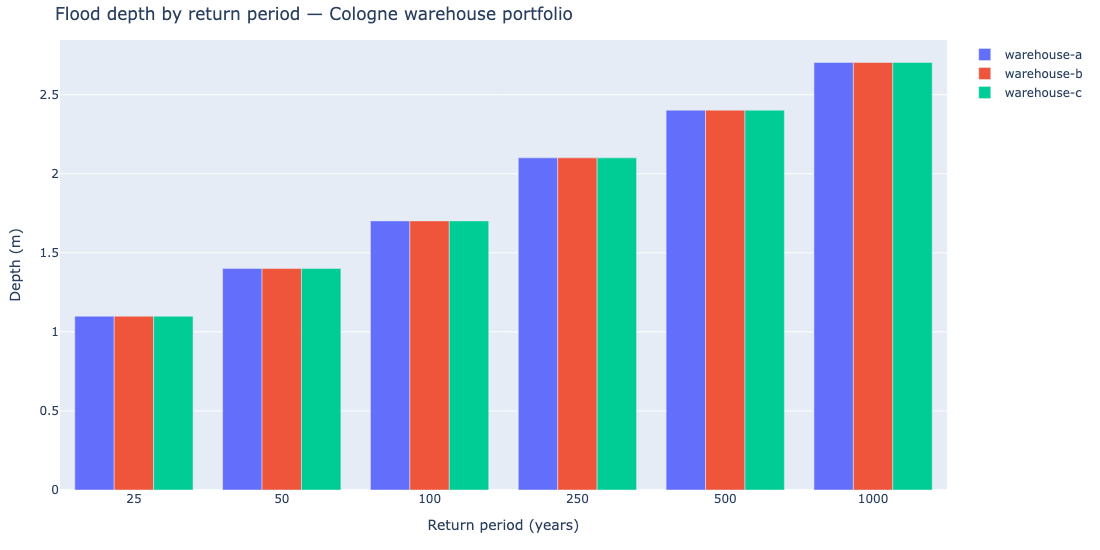

In [7]:
value_cols = list(result.value_columns)
long = evaluated.melt(
    id_vars=["asset_id"],
    value_vars=value_cols,
    var_name="rp_column",
    value_name="depth_m",
)
long["return_period"] = [int(c.split("rp")[-1]) for c in long["rp_column"]]

fig_bars = go.Figure()
for asset_id, frame in long.groupby("asset_id"):
    frame = frame.sort_values("return_period")
    fig_bars.add_trace(
        go.Bar(
            x=[str(rp) for rp in frame["return_period"]],
            y=frame["depth_m"],
            name=asset_id,
        )
    )
fig_bars.update_layout(
    barmode="group",
    title="Flood depth by return period — Cologne warehouse portfolio",
    xaxis_title="Return period (years)",
    yaxis_title="Depth (m)",
    margin=dict(l=60, r=40, t=40, b=60),
)
fig_bars.show()


## Scaling this up

[`pipelines/asset_portfolio_pipeline.py`](https://github.com/RiskThinking/crc-docs/blob/main/pipelines/asset_portfolio_pipeline.py)
is this notebook's headless twin. Supply larger canonical hazard and asset
Parquets with `--hazard-input` / `--asset-input` and raise `--max-workers`; the
evaluator streams in bounded Arrow batches either way.
